## ROS1 Kinase Mutant Analysis

Goal:
To determine whether mutation-driven differences are explained by:

- global conformational basin shifts
- local structural motif changes
- or a combination of both

## Analysis strategy

1. Identify dominant conformational motions using PCA
2. Define major conformational basins along PC1
3. Quantify mutation effects on basin occupancy and dynamics
4. Test coupling between basins and structural motifs (A-loop, DFG)
5. Interpret the dominant motion mechanistically
6. Perform targeted LDA analysis on the Q2022P family

In [1]:
# import necessary libraries
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt


In [2]:
# Forcing notebook to behave as if it is being run from ROS1_analysis/ to prevent errors
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")

print("Working directory:", os.getcwd())

Working directory: /homes/lkgyammerah/ROS1_analysis


In [3]:

# load data

STAGE1 = Path("analysis/outputs/stage1_common_align")
FURTHER = Path("analysis/outputs/stage2_further_analysis")
ALOOP = Path("analysis/outputs/stage2_aloop_state_labels")
DFG = Path("analysis/outputs/stage2_dfg_chi1_final")

F = np.load(STAGE1 / "F.npy", allow_pickle=True).tolist()

basin_flat = np.load(FURTHER / "basin_flat.npy")
x_owner = np.load(FURTHER / "x_owner.npy")

def load_list_npz(path):
    z = np.load(path)
    keys = sorted(z.files, key=lambda x: int(x.split("_")[1]))
    return [z[k] for k in keys]

ACT_state = load_list_npz(ALOOP / "ACT_state_list.npz")
DFG_state = load_list_npz(DFG / "DFG_state_list.npz")

# reconstruct basin per trajectory
basin = [basin_flat[x_owner == ti] for ti in range(len(F))]

## PCA-defined conformational basins

Principal component analysis (PCA) reveals two dominant conformational basins (PC1).
These basins represent the major modes of motion of the kinase.

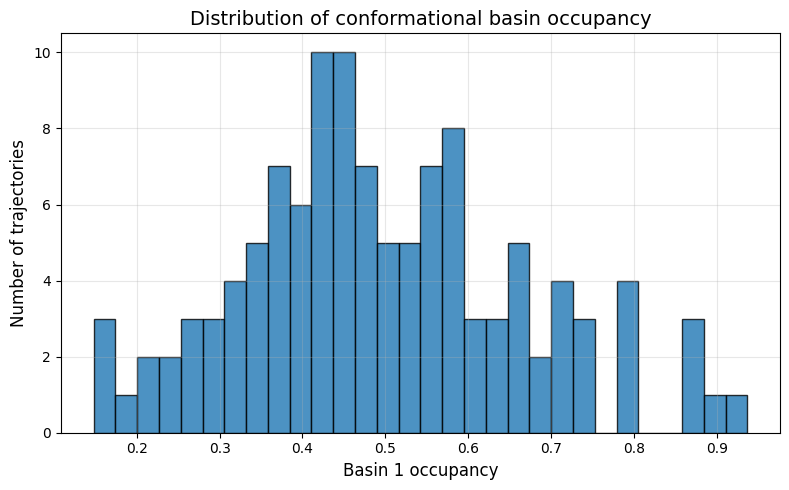

In [4]:

means = [np.mean(basin[i]) for i in range(len(F))]

plt.figure(figsize=(8,5))

plt.hist(means, bins=30, edgecolor='black', alpha=0.8)

plt.xlabel("Basin 1 occupancy", fontsize=12)
plt.ylabel("Number of trajectories", fontsize=12)
plt.title("Distribution of conformational basin occupancy", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Mutational effects on basin occupancy

We compare how different mutations shift conformational preferences relative to WT.

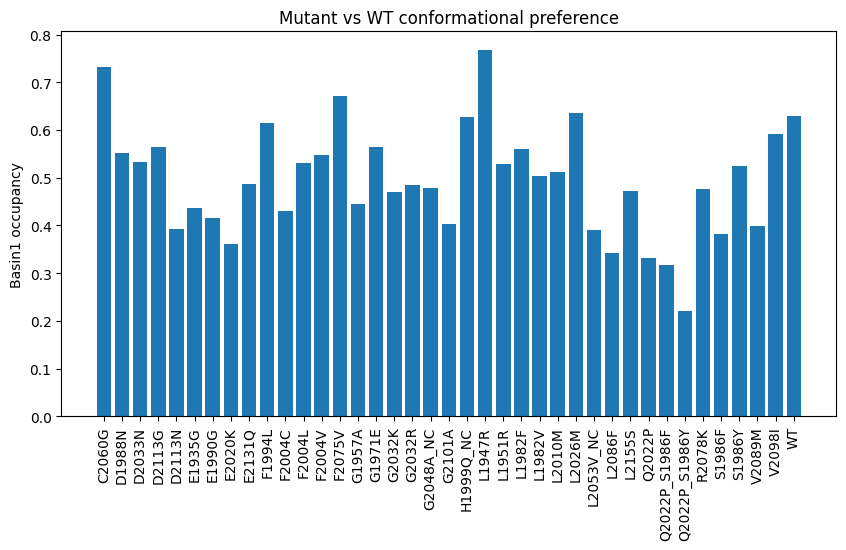

In [5]:
mutant_of = np.array([p.split("/")[0] for p in F])
uniq = np.unique(mutant_of)

means = []
for mut in uniq:
    idx = np.where(mutant_of == mut)[0]
    vals = [np.mean(basin[i]) for i in idx]
    means.append(np.mean(vals))

plt.figure(figsize=(10,5))
plt.bar(uniq, means)
plt.xticks(rotation=90)
plt.ylabel("Basin1 occupancy")
plt.title("Mutant vs WT conformational preference")
plt.show()

## Conformational dynamics

We quantify how frequently trajectories switch between PCA-defined basins.

In [6]:
def switch_count(x):
    x = np.asarray(x, dtype=int)
    if len(x) < 2:
        return 0
    return int(np.sum(x[1:] != x[:-1]))

def dwell_time(x):
    x = np.asarray(x, dtype=int)
    if len(x) == 0:
        return np.nan
    runs = []
    run = 1
    for i in range(1, len(x)):
        if x[i] == x[i-1]:
            run += 1
        else:
            runs.append(run)
            run = 1
    runs.append(run)
    return float(np.mean(runs))

sw = np.array([switch_count(basin[i]) for i in range(len(F))], dtype=float)
dw = np.array([dwell_time(basin[i]) for i in range(len(F))], dtype=float)

print("sw shape:", sw.shape)
print("dw shape:", dw.shape)

sw shape: (117,)
dw shape: (117,)


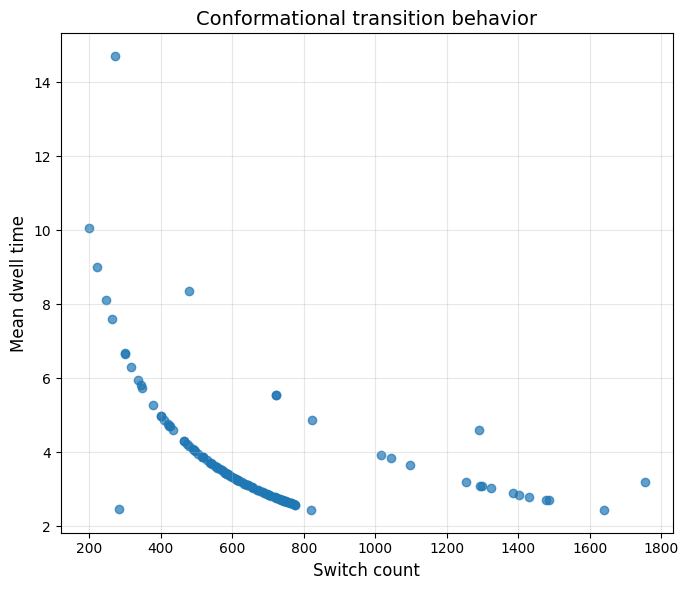

In [7]:
plt.figure(figsize=(7,6))

plt.scatter(sw, dw, alpha=0.7)

plt.xlabel("Switch count", fontsize=12)
plt.ylabel("Mean dwell time", fontsize=12)
plt.title("Conformational transition behavior", fontsize=14)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Coupling to A-loop state

We tested whether PCA basins correspond to activation-loop (A-loop) states.

In [8]:
all_b = np.concatenate(basin)
all_a = np.concatenate(ACT_state)

m = min(len(all_b), len(all_a))
all_b = all_b[:m]
all_a = all_a[:m]

for b in [0,1]:
    print("P(A-loop inactive | basin =", b, ") =", np.mean(all_a[all_b == b]))

P(A-loop inactive | basin = 0 ) = 0.5150576467948672
P(A-loop inactive | basin = 1 ) = 0.4849386254414915


## Coupling to DFG state

We also tested whether PCA basins correspond to DFG conformational states.

In [9]:
b_trim = []
d_trim = []

for i in range(len(F)):
    m = min(len(basin[i]), len(DFG_state[i]))
    b_trim.append(basin[i][:m])
    d_trim.append(DFG_state[i][:m])

all_b = np.concatenate(b_trim)
all_d = np.concatenate(d_trim)

for b in [0,1]:
    print("P(DFG | basin =", b, ") =", np.mean(all_d[all_b == b]))

P(DFG | basin = 0 ) = 0.5214865363334563
P(DFG | basin = 1 ) = 0.5247267185200757


## Mechanistic interpretation

The dominant PCA-defined conformational basins are not strongly coupled to either A-loop or DFG structural states.

Both A-loop and DFG show nearly equal probabilities across the two basins, indicating that PC1 does not represent a simple activation-related transition.

Instead, PC1 captures a broader, global conformational motion of the kinase domain.

Mutations reshape this conformational landscape by:
1. Redistributing basin occupancy (global motion)
2. Independently biasing structural motifs such as the A-loop and DFG

Thus, ROS1 mutations act on multiple partially independent layers of conformational regulation.

## Structural interpretation of PC1 motion

To understand the physical meaning of the dominant PCA coordinate (PC1), we extract representative structures corresponding to:

- Low PC1 values (one extreme)
- High PC1 values (opposite extreme)
- Representative structures from each basin

### Objective

To determine:

> What structural changes does PC1 actually represent?

---

### Approach

- Identify frames at extreme ends of PC1
- Select representative structures (e.g., medoids)
- Visualize structures in PyMOL

---

### Interpretation

By comparing these structures, we can assess:

- Relative movement of N-lobe and C-lobe
- Opening/closing of the kinase cleft
- Changes in A-loop, DFG, and αC helix positioning

---

### Expected outcome

Based on previous analysis:

- PC1 is not dominated by A-loop or DFG transitions
- Therefore, structural differences are expected to reflect:

> A broader, collective rearrangement of the kinase domain

---

### Role in the analysis

This step connects:

- **Abstract PCA space**
- to
- **physical structural changes**

and provides the final validation of the mechanistic interpretation.

## Highlighting selected mutants on switch vs dwell

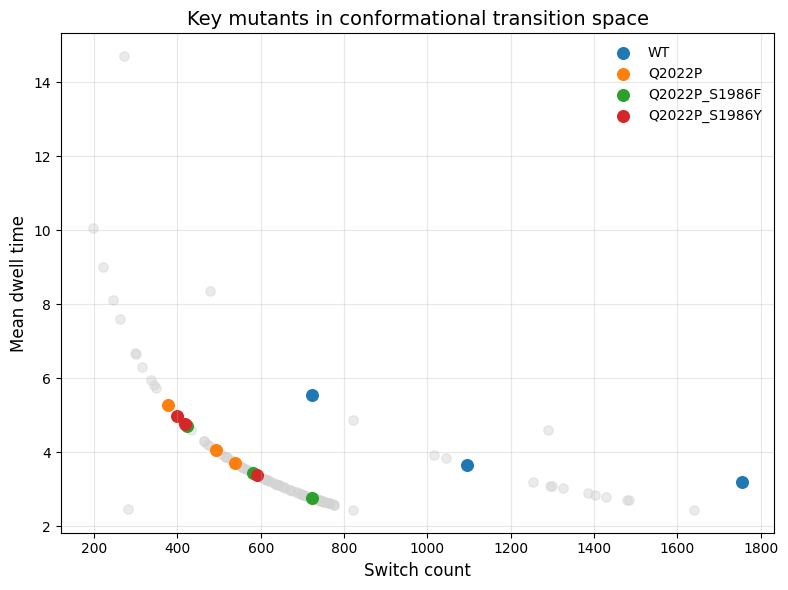

In [10]:

mutant_of = np.array([p.split("/")[0] for p in F])

interesting = ["WT", "Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"]

plt.figure(figsize=(8,6))

# background
for i, mut in enumerate(mutant_of):
    if mut not in interesting:
        plt.scatter(sw[i], dw[i], color="lightgray", alpha=0.45, s=45)

# highlighted
for mut in interesting:
    idx = np.where(mutant_of == mut)[0]
    plt.scatter(sw[idx], dw[idx], s=70, label=mut)

plt.xlabel("Switch count", fontsize=12)
plt.ylabel("Mean dwell time", fontsize=12)
plt.title("Key mutants in conformational transition space", fontsize=14)
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

This plot summarizes conformational dynamics using two complementary metrics:

- **Switch count** (x-axis): number of transitions between basins  
- **Mean dwell time** (y-axis): average time spent in a basin before transitioning  

These quantities are inversely related:

- High switch count → low dwell time → highly dynamic behavior  
- Low switch count → high dwell time → more stable behavior  

WT exhibits high switching and low dwell time, indicating a highly dynamic system.

In contrast, Q2022P and its variants show reduced switching and increased dwell time, indicating stabilization within specific conformational states.

## Highlight selected mutants on basin occupancy

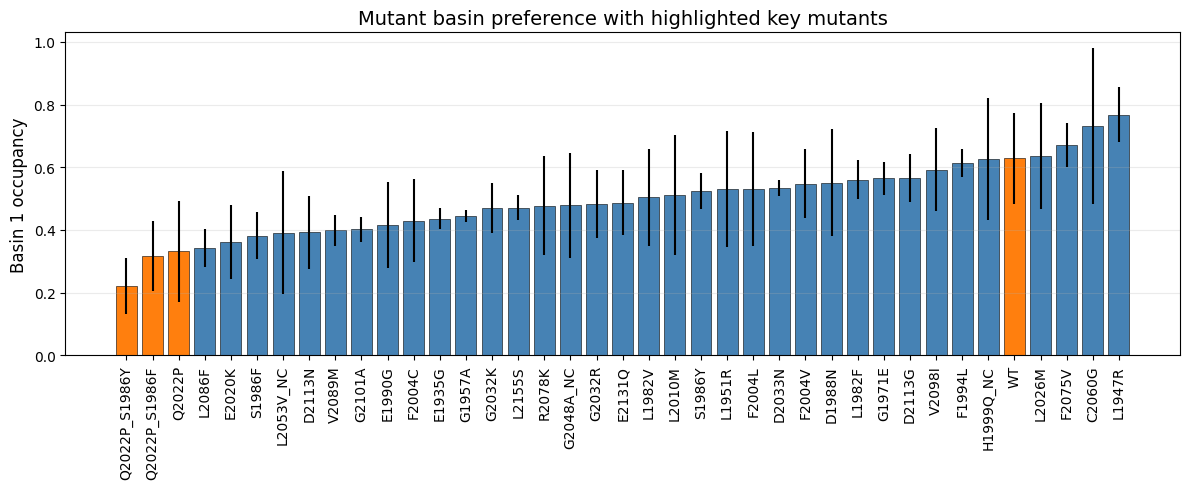

In [ ]:
mutant_of = np.array([p.split("/")[0] for p in F])
uniq = np.unique(mutant_of)

means = []
stds = []
for mut in uniq:
    idx = np.where(mutant_of == mut)[0]
    vals = [np.mean(basin[i]) for i in idx]
    means.append(np.mean(vals))
    stds.append(np.std(vals))

means = np.array(means)
stds = np.array(stds)

interesting = {"WT", "Q2022P", "Q2022P_S1986F", "Q2022P_S1986Y"}

order = np.argsort(means)
uniq_ord = uniq[order]
means_ord = means[order]
stds_ord = stds[order]

colors = ["tab:orange" if m in interesting else "steelblue" for m in uniq_ord]

plt.figure(figsize=(12,5))
plt.bar(uniq_ord, means_ord, yerr=stds_ord, color=colors, edgecolor="black", linewidth=0.4)
plt.xticks(rotation=90)
plt.ylabel("Basin 1 occupancy", fontsize=12)
plt.title("Mutant basin preference with highlighted key mutants", fontsize=14)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Interpretation of highlighted mutants

WT occupies a relatively high-basin regime and remains dynamically flexible.  
The Q2022P family shifts basin preference away from WT, but does not become completely locked.  
This suggests that these mutants alter the conformational landscape rather than simply freezing the kinase in one structural state.

## Supervised analysis of the Q2022P mutant family (LDA)

While PCA revealed the dominant conformational landscape of the full dataset, we performed a **targeted supervised analysis** to investigate differences within the **Q2022P mutant family**.

### Objective

The Q2022P family consists of closely related variants:

- Q2022P  
- Q2022P_S1986F  
- Q2022P_S1986Y  

These mutations are expected to induce **subtle but meaningful shifts** in conformational behavior.

We therefore ask:

> Can these mutants be distinguished based on their conformational features?

---

### Approach

- Input: **PCA-derived features**
- Features were averaged per trajectory to capture overall conformational tendencies
- Linear Discriminant Analysis (LDA) was used to:
  - maximize separation between mutants
  - identify directions that best distinguish their conformational ensembles

### Multi-class LDA (trajectory-level separation)

We first perform LDA across all Q2022P-family mutants.

Each point represents a **trajectory-level average** projected onto the first discriminant axis (LD1).

### Interpretation

- The mutants show **partial but consistent separation along LD1**
- This indicates that each mutant exhibits a **distinct conformational bias at the ensemble level**

However:

> The separation is not absolute, suggesting that the mutants still explore overlapping regions of conformational space.

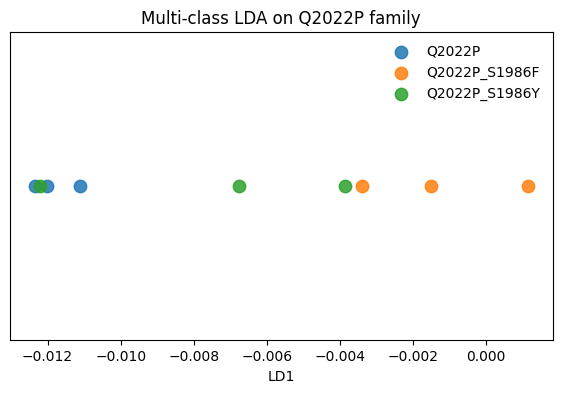

In [19]:
# multi-class LDA  # trajectory mean
LDA_DIR = Path("analysis/outputs/stage2_lda_qfamily")

Z_multiclass = np.load(LDA_DIR / "Z_multiclass.npy")
names_qfamily = np.load(LDA_DIR / "names_qfamily.npy", allow_pickle=True)

plt.figure(figsize=(7,4))
for name in np.unique(names_qfamily):
    zz = Z_multiclass[names_qfamily == name, 0]
    plt.scatter(zz, np.zeros_like(zz), s=80, alpha=0.85, label=name)

plt.xlabel("LD1")
plt.yticks([])
plt.title("Multi-class LDA on Q2022P family")
plt.legend(frameon=False)
plt.show()

### Multi-class frame-level projection onto LD1

To further investigate how these mutants explore conformational space, all frames from each system were projected onto the LD1 axis obtained from the multi-class LDA.

### Interpretation

- The distributions for different mutants show **significant overlap**
- However, their **centers and spreads differ slightly**

This indicates that:

> While mutants are distinguishable at the trajectory (ensemble) level, they still sample a largely **shared conformational space** at the frame level.

### Key insight

- LDA separation at the trajectory level reflects **differences in overall conformational preference**
- At the frame level, the overlap suggests:
  - no completely distinct structural states
  - but **shifted sampling within the same global landscape**

This is consistent with the broader PCA results:

> Mutations do not introduce entirely new conformations, but instead **bias how the kinase explores existing states**.

In [20]:
# frame-level # multiclass LDA

LDA_DIR = Path("analysis/outputs/stage2_lda_qfamily")

def load_list_npz(path):
    z = np.load(path, allow_pickle=True)
    keys = sorted(z.files, key=lambda x: int(x.split("_")[1]))
    return [np.asarray(z[k]) for k in keys]

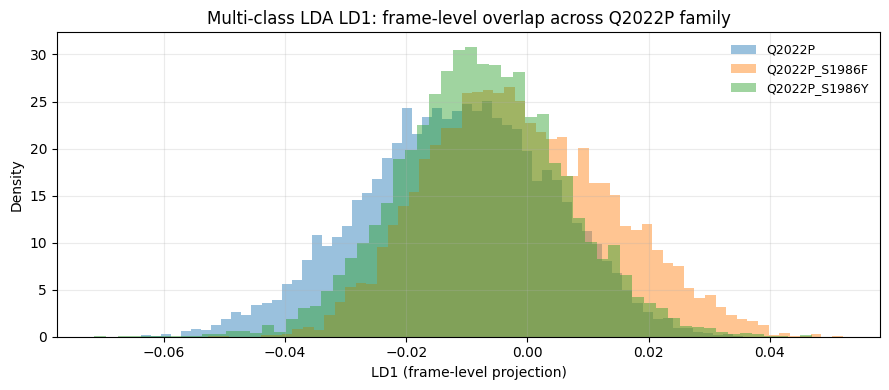

In [21]:
ld1_mc_frames = load_list_npz(LDA_DIR / "ld1_multiclass_frames_qfamily.npz")
names_qfamily = np.load(LDA_DIR / "names_qfamily.npy", allow_pickle=True)

plt.figure(figsize=(9,4))

for sys_name in np.unique(names_qfamily):
    vals = np.concatenate([ld1_mc_frames[i] for i in range(len(names_qfamily)) if names_qfamily[i] == sys_name])
    plt.hist(vals, bins=60, alpha=0.45, density=True, label=sys_name)

plt.xlabel("LD1 (frame-level projection)")
plt.ylabel("Density")
plt.title("Multi-class LDA LD1: frame-level overlap across Q2022P family")
plt.legend(frameon=False, fontsize=9)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Pairwise LDA comparison

To better resolve differences, we perform pairwise LDA between closely related mutants.

### Interpretation

- Pairwise comparisons show **clearer separation than the multi-class case**
- This indicates that specific mutations (e.g., S1986F vs S1986Y) introduce **detectable shifts in conformational preference**

> These differences are subtle but systematic, and become more apparent when comparing mutants directly.

In [22]:
# pairwise , trajectory meaan

def plot_pairwise_mean_scatter(pair_name, A, B, nA=3, nB=3, lda_dir=LDA_DIR):
    ld1_frames = load_list_npz(lda_dir / f"ld1_frames_{pair_name}.npz")

    # compute means per trajectory
    ld1_means = np.array([arr.mean() for arr in ld1_frames])

    labels = np.array([A]*nA + [B]*nB)

    plt.figure(figsize=(5,5))

    for sys in [A, B]:
        m = labels == sys
        y = np.random.normal(0, 0.02, size=np.sum(m))  # jitter
        plt.scatter(ld1_means[m], y, s=80, label=sys)

    plt.xlabel("LD1 (trajectory means)")
    plt.title(f"LDA separation: {A} vs {B}")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

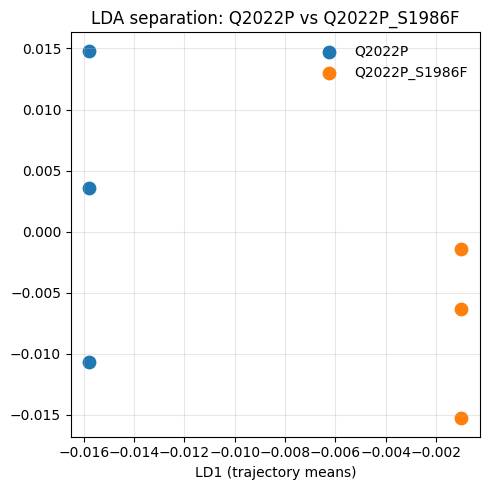

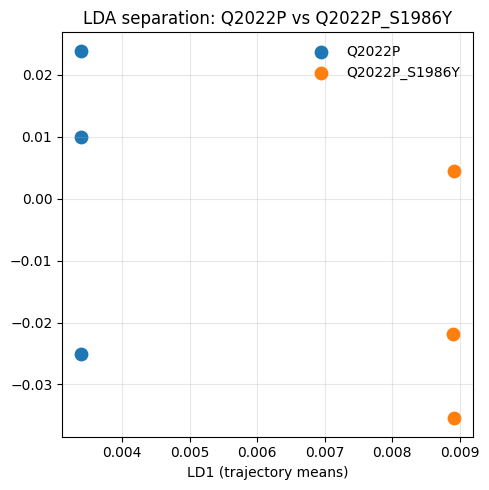

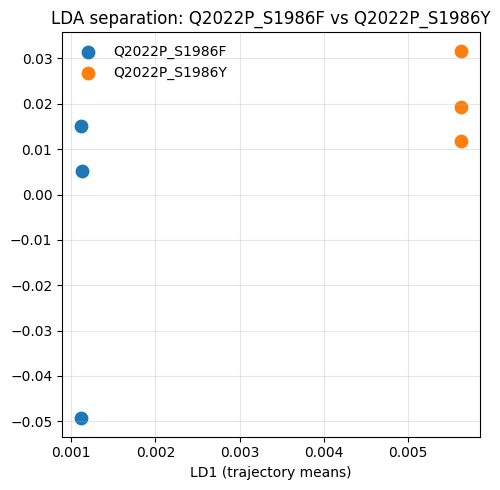

In [23]:
plot_pairwise_mean_scatter("Q2022P_vs_Q2022P_S1986F", "Q2022P", "Q2022P_S1986F")
plot_pairwise_mean_scatter("Q2022P_vs_Q2022P_S1986Y", "Q2022P", "Q2022P_S1986Y")
plot_pairwise_mean_scatter("Q2022P_S1986F_vs_Q2022P_S1986Y", "Q2022P_S1986F", "Q2022P_S1986Y")

### Frame-level projection onto LD1

To assess whether mutants occupy distinct structural states or overlapping ensembles, all frames were projected onto the learned LD1 axis.

### Key insight

- Frame-level distributions show **substantial overlap between mutants**
- However, their **distribution centers are shifted**

This reveals an important distinction:

> Mutants do not form completely separate structural states, but instead exhibit **biased sampling of a shared conformational landscape**

### Interpretation in context

- LDA separation at the trajectory level reflects **ensemble-level differences**
- Overlap at the frame level indicates that:
  - the underlying conformational space is largely shared
  - mutations shift **probabilities**, not create entirely new states

In [24]:

# pairwise , frame-level overlap
def plot_pairwise_ld1_hist(pair_name, A, B, nA=3, nB=3, lda_dir=LDA_DIR):
    ld1_frames = load_list_npz(lda_dir / f"ld1_frames_{pair_name}.npz")
    names_pair = np.array([A] * nA + [B] * nB, dtype=object)

    valsA = np.concatenate([ld1_frames[i] for i in range(len(names_pair)) if names_pair[i] == A])
    valsB = np.concatenate([ld1_frames[i] for i in range(len(names_pair)) if names_pair[i] == B])

    plt.figure(figsize=(8,4))
    plt.hist(valsA, bins=60, alpha=0.55, density=True, label=A)
    plt.hist(valsB, bins=60, alpha=0.55, density=True, label=B)

    plt.xlabel("LD1 (frame-level projection)")
    plt.ylabel("Density")
    plt.title(f"Frame-level overlap: {A} vs {B}")
    plt.legend(frameon=False)
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

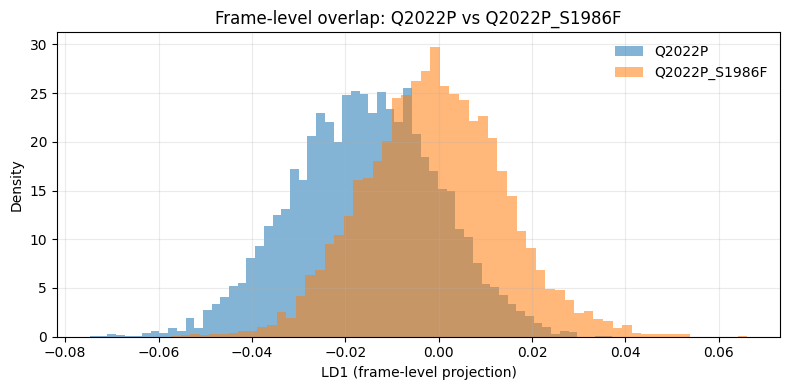

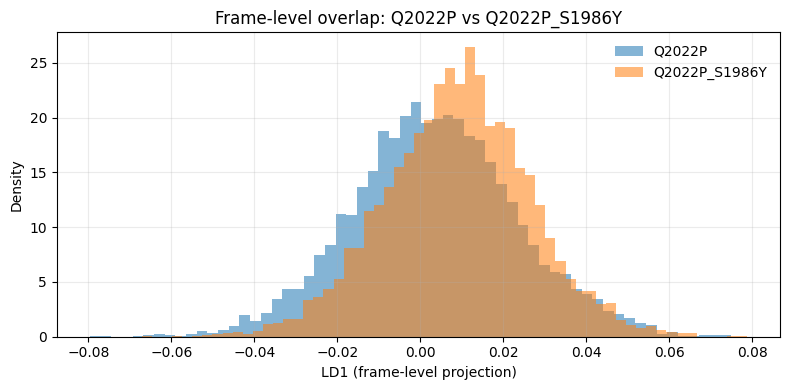

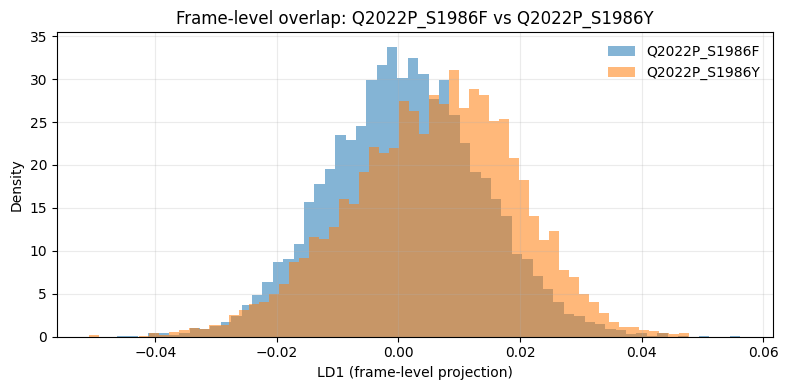

In [25]:
plot_pairwise_ld1_hist("Q2022P_vs_Q2022P_S1986F", "Q2022P", "Q2022P_S1986F")
plot_pairwise_ld1_hist("Q2022P_vs_Q2022P_S1986Y", "Q2022P", "Q2022P_S1986Y")
plot_pairwise_ld1_hist("Q2022P_S1986F_vs_Q2022P_S1986Y", "Q2022P_S1986F", "Q2022P_S1986Y")

### Role of LDA in the overall analysis

This analysis complements the PCA-based findings:

- **PCA** identifies dominant global motions and conformational basins  
- **LDA** reveals subtle, mutation-specific shifts within those basins  

Together, these results indicate that:

> Mutations in the Q2022P family do not create entirely new conformational states, but instead modulate how the kinase samples an existing global landscape.